## ВКР

**Тема**:  «Разработка модуля предобработки данных с оценкой влияния шагов очистки и генерации признаков на интерпретируемость моделей»

План ВКР (основные вопросы, подлежащие исследованию и разработке):

Теоретические основы предобработки данных, моделирования и интерпретируемости

1.1. Методы предобработки данных

1.2. Алгоритмы машинного обучения, используемые в исследовании

1.3. Методы интерпретируемости моделей

Анализ данных и постановка исследовательской задачи

2.1. Описание и анализ используемого набора данных

2.2 Формулировка целей, задач и исследовательских гипотез

2.3. Требования к модулю предобработки и архитектурные решения

Разработка и исследование модуля предобработки данных

3.1. Архитектура и реализация модуля предобработки

3.2. Интеграция модуля с модельным пайплайном

3.3. Экспериментальная оценка влияния предобработки на качество и интерпретируемость моделей



Датасет: Online Retail (UCI)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel('Online Retail.xlsx')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## EDA

In [4]:
print("Размер:", data.shape)

# Типы колонок и пропуски
print(data.info())

# Количество пропусков в каждой колонке
print(data.isnull().sum())

Размер: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
print(data[['Quantity', 'UnitPrice']].describe())

# Проверка на отрицательные значения
print((data[['Quantity', 'UnitPrice']] <= 0).sum())

            Quantity      UnitPrice
count  541909.000000  541909.000000
mean        9.552250       4.611114
std       218.081158      96.759853
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000
Quantity     10624
UnitPrice     2517
dtype: int64


In [11]:
print("Количество стран:", data['Country'].nunique(), '\n')
print(data['Country'].value_counts().head(10), '\n')  # Топ 10 стран по числу транзакций

# Уникальные описания товаров
print("Количество уникальных товаров:", data['Description'].nunique(), '\n') 

print("Топ 10 товаров", data['Description'].value_counts().head(10))

Количество стран: 38 

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64 

Количество уникальных товаров: 4223 

Топ 10 товаров Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64


In [12]:
# Пропуски в CustomerID
print("Пропущенные CustomerID:", data['CustomerID'].isnull().sum(), '\n')

# Проверка InvoiceNo на возвраты (обычно с 'C' в начале)
print("Количество возвратов:", data['InvoiceNo'].str.startswith('C').sum())

Пропущенные CustomerID: 135080 

Количество возвратов: 9288


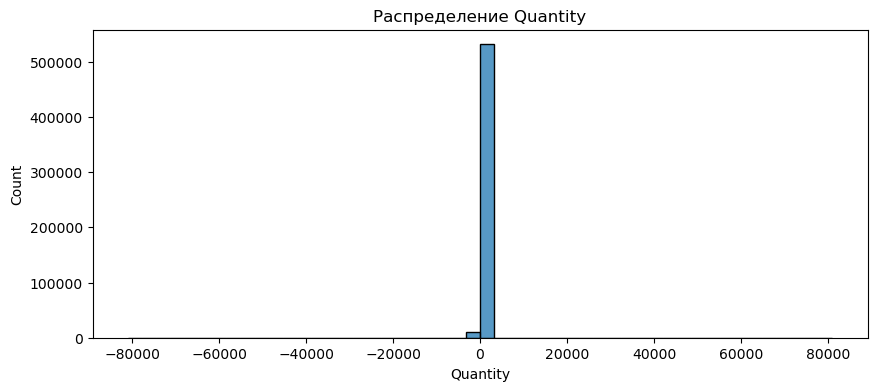

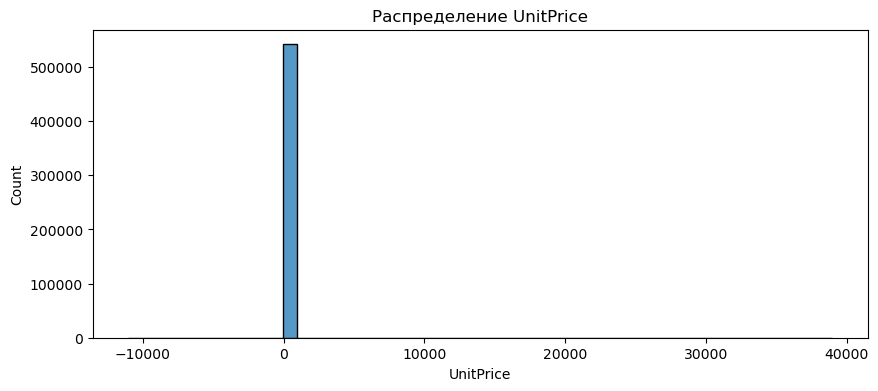

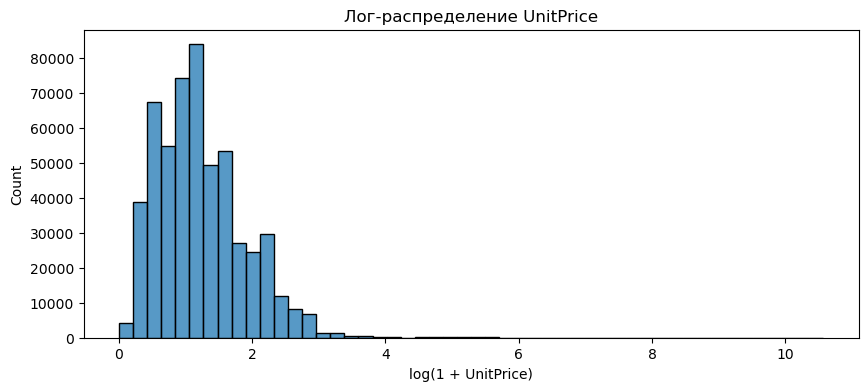

In [16]:
plt.figure(figsize=(10,4))
sns.histplot(data['Quantity'], bins=50, kde=False)
plt.title('Распределение Quantity')
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(data['UnitPrice'], bins=50, kde=False)
plt.title('Распределение UnitPrice')
plt.show()


plt.figure(figsize=(10,4))

# убираем нули и отрицательные значения
filtered_price = data[data['UnitPrice'] > 0]['UnitPrice']

sns.histplot(np.log1p(filtered_price), bins=50)
plt.title('Лог-распределение UnitPrice')
plt.xlabel('log(1 + UnitPrice)')
plt.show()

Найдем выбросы

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower) | (data[column] > upper)]
    
    return outliers, lower, upper


outliers, low, high = detect_outliers_iqr(data, 'Quantity')
print(len(outliers))

58619


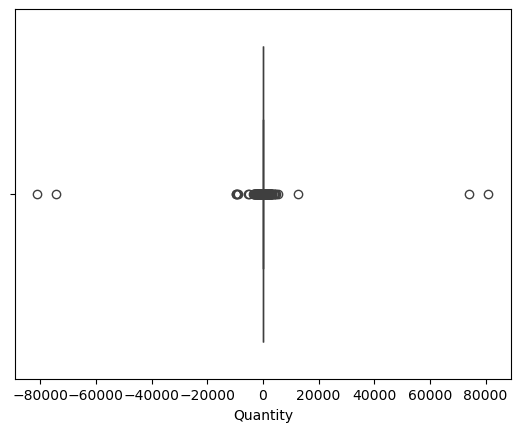

In [ ]:
sns.boxplot(x=data['Quantity'])
plt.show()

C:\Users\Полина\AppData\Local\Temp\ipykernel_9712\3745715093.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = data['InvoiceNo'].resample('M').count()


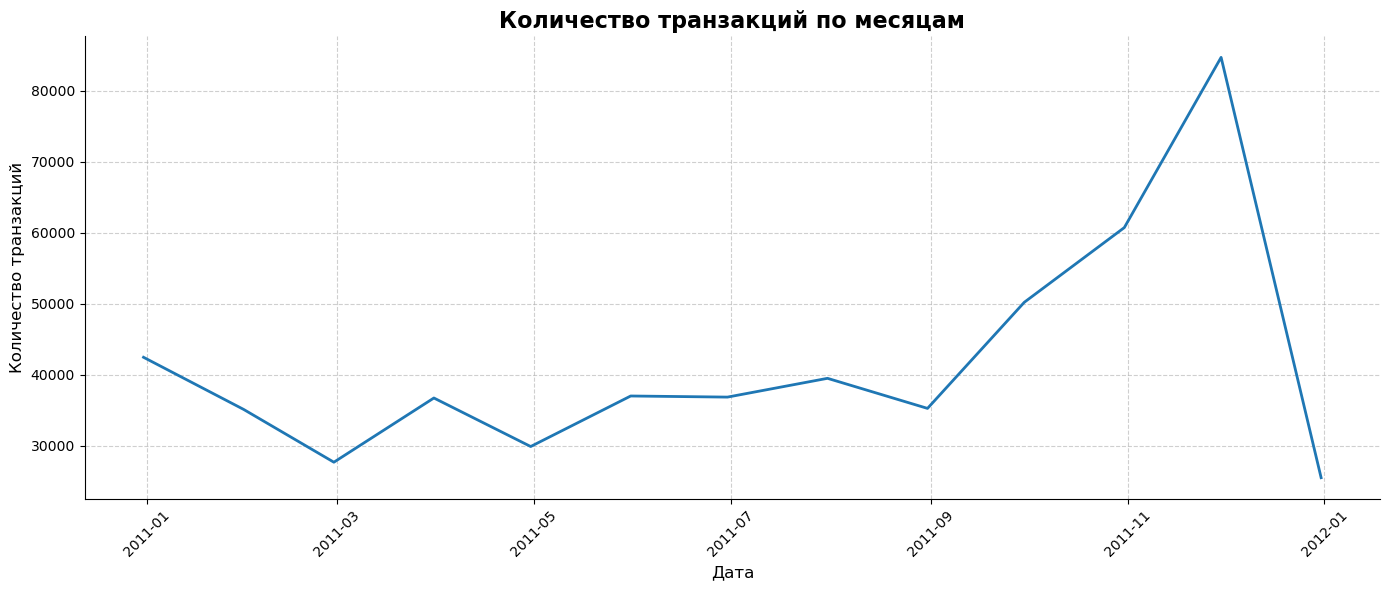

In [ ]:

data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data.set_index('InvoiceDate', inplace=True)

monthly_counts = data['InvoiceNo'].resample('M').count()

# Построение графика
plt.figure(figsize=(14, 6))

plt.plot(monthly_counts.index, monthly_counts.values, linewidth=2)

# Оформление
plt.title('Количество транзакций по месяцам', fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество транзакций', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.xticks(rotation=45)
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# Возвращаем индекс
data.reset_index(inplace=True)

In [15]:
country_summary = data.groupby('Country').agg({
    'InvoiceNo': 'nunique',
    'CustomerID': 'nunique',
    'Quantity': 'sum',
    'UnitPrice': 'mean'
}).sort_values(by='InvoiceNo', ascending=False)

import pandas as pd
pd.set_option('display.max_rows', 50)
print(country_summary)

                      InvoiceNo  CustomerID  Quantity   UnitPrice
Country                                                          
United Kingdom            23494        3950   4263829    4.532422
Germany                     603          95    117448    3.966930
France                      461          87    110480    5.028864
EIRE                        360           3    142637    5.911077
Belgium                     119          25     23152    3.644335
Spain                       105          31     26824    4.987544
Netherlands                 101           9    200128    2.738317
Switzerland                  74          21     30325    3.403442
Portugal                     71          19     16180    8.582976
Australia                    69           9     83653    3.220612
Italy                        55          15      7999    4.831121
Finland                      48          12     10666    5.448705
Sweden                       46           8     35637    3.910887
Norway    